# 02 — Attention from Scratch
Implements scaled dot-product attention step by step.

In [1]:
import math, torch, matplotlib.pyplot as plt

## Step 1: What are Q, K, V?
Q = what this token is looking for
K = what this token has to offer
V = the content this token contributes if attended to

In [2]:
torch.manual_seed(0)
T, d_k = 6, 8   # 6 tokens, 8-dim keys
Q = torch.randn(T, d_k)
K = torch.randn(T, d_k)
V = torch.randn(T, d_k)

## Step 2: Scaled dot-product — WHY we scale by sqrt(d_k)

In [3]:
scores_unscaled = Q @ K.T
scores_scaled   = Q @ K.T / math.sqrt(d_k)
print(f"Unscaled std: {scores_unscaled.std():.2f}")
print(f"Scaled   std: {scores_scaled.std():.2f}")
# Unscaled softmax becomes one-hot (model only looks at one token)
print(f"\nUnscaled softmax (first row): {torch.softmax(scores_unscaled[0], dim=-1).round(decimals=2)}")
print(f"Scaled   softmax (first row): {torch.softmax(scores_scaled[0],   dim=-1).round(decimals=2)}")

Unscaled std: 2.32
Scaled   std: 0.82

Unscaled softmax (first row): tensor([0.1700, 0.0100, 0.0700, 0.6800, 0.0800, 0.0000])
Scaled   softmax (first row): tensor([0.2200, 0.0700, 0.1600, 0.3500, 0.1700, 0.0400])


## Step 3: Causal mask — prevent attending to future tokens

In [4]:
mask = torch.tril(torch.ones(T, T))
scores_masked = scores_scaled.masked_fill(mask == 0, float('-inf'))
weights = torch.softmax(scores_masked, dim=-1)
print("\nAttention weights (should be lower-triangular, no future tokens):")
print(weights.round(decimals=2))


Attention weights (should be lower-triangular, no future tokens):
tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3600, 0.6400, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2600, 0.6500, 0.0900, 0.0000, 0.0000, 0.0000],
        [0.2300, 0.1600, 0.4000, 0.2100, 0.0000, 0.0000],
        [0.1600, 0.1900, 0.1400, 0.2300, 0.2800, 0.0000],
        [0.0700, 0.0100, 0.7000, 0.1200, 0.0500, 0.0500]])


## Step 4: Visualise attention

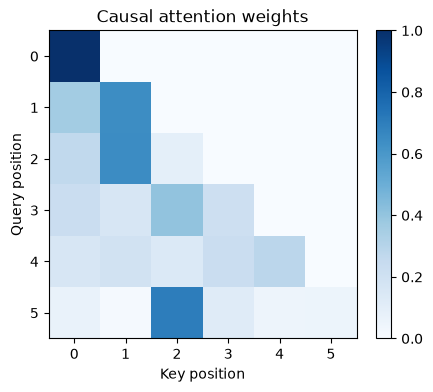

In [5]:
plt.figure(figsize=(5, 4))
plt.imshow(weights.detach().numpy(), cmap="Blues")
plt.title("Causal attention weights"); plt.colorbar()
plt.xlabel("Key position"); plt.ylabel("Query position")
plt.savefig("../benchmarks/plots/attention_weights.png", dpi=100, bbox_inches="tight")
plt.show()